In [1]:
import subprocess
subprocess.run(['pip', 'install', 'planetary-computer', 'pystac-client', 'odc-stac'], 
               capture_output=True, text=True)
print("Installazione completata!")

Installazione completata!


In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# Carica la banda termica
st_path = r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\LC08_L2SP_198024_20240811_20240815_02_T1_ST_B10.TIF"

with rasterio.open(st_path) as src:
    print(f"Dimensioni: {src.width} x {src.height} pixel")
    print(f"CRS: {src.crs}")
    print(f"Risoluzione: {src.res} metri")
    print(f"Bounds: {src.bounds}")
    
    st_raw = src.read(1).astype(float)
    transform = src.transform
    crs = src.crs

print(f"Valore minimo raw: {st_raw[st_raw > 0].min()}")
print(f"Valore massimo raw: {st_raw.max()}")

Dimensioni: 7791 x 7901 pixel
CRS: EPSG:32631
Risoluzione: (30.0, 30.0) metri
Bounds: BoundingBox(left=529185.0, bottom=5609985.0, right=762915.0, top=5847015.0)
Valore minimo raw: 38325.0
Valore massimo raw: 55446.0


In [3]:
# Convertiamo in gradi Celsius
# Formula ufficiale USGS Landsat Collection 2
st_kelvin = st_raw * 0.00341802 + 149.0
st_celsius = st_kelvin - 273.15

# Mascheriamo i valori non validi (pixel = 0)
st_celsius = np.where(st_raw > 0, st_celsius, np.nan)

print(f"Temperatura minima: {np.nanmin(st_celsius):.1f} °C")
print(f"Temperatura massima: {np.nanmax(st_celsius):.1f} °C")
print(f"Temperatura media: {np.nanmean(st_celsius):.1f} °C")

Temperatura minima: 6.8 °C
Temperatura massima: 65.4 °C
Temperatura media: 29.7 °C


In [4]:
from rasterio.windows import from_bounds

with rasterio.open(st_path) as src:
    window = from_bounds(612000, 5797000, 652000, 5812000, src.transform)
    st_raw_ams = src.read(1, window=window).astype(float)

st_kelvin_ams = st_raw_ams * 0.00341802 + 149.0
st_celsius_ams = st_kelvin_ams - 273.15
st_celsius_ams = np.where(st_raw_ams > 0, st_celsius_ams, np.nan)

print(f"Amsterdam — Temperatura minima: {np.nanmin(st_celsius_ams):.1f} °C")
print(f"Amsterdam — Temperatura massima: {np.nanmax(st_celsius_ams):.1f} °C")
print(f"Amsterdam — Temperatura media: {np.nanmean(st_celsius_ams):.1f} °C")

Amsterdam — Temperatura minima: 10.2 °C
Amsterdam — Temperatura massima: 54.0 °C
Amsterdam — Temperatura media: 28.0 °C


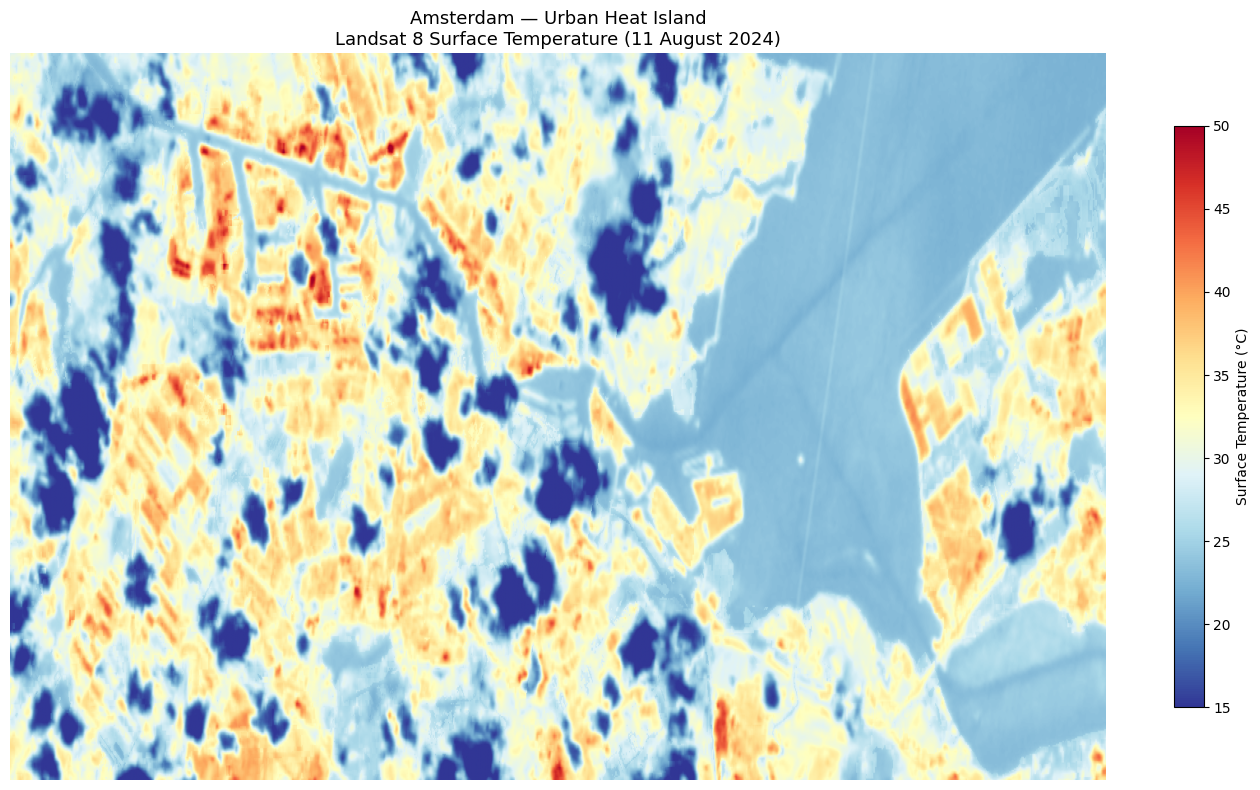

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))

img = ax.imshow(
    st_celsius_ams,
    cmap='RdYlBu_r',
    vmin=15,
    vmax=50,
    aspect='auto'
)

plt.colorbar(img, ax=ax, label='Surface Temperature (°C)', shrink=0.8)
ax.set_title('Amsterdam — Urban Heat Island\nLandsat 8 Surface Temperature (11 August 2024)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_heat_island.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from scipy.ndimage import zoom

# Il nostro NDVI da Sentinel-2 ha dimensioni diverse dal Landsat
print(f"Dimensioni NDVI: {ndvi.shape}")
print(f"Dimensioni temperatura: {st_celsius_ams.shape}")

# Ricampionamo NDVI alla stessa dimensione del Landsat
# Calcoliamo il fattore di scala
scale_y = st_celsius_ams.shape[0] / ndvi.shape[0]
scale_x = st_celsius_ams.shape[1] / ndvi.shape[1]

ndvi_resampled = zoom(ndvi, (scale_y, scale_x), order=1)
print(f"NDVI ricampionato: {ndvi_resampled.shape}")

NameError: name 'ndvi' is not defined

In [7]:
# Ricalcoliamo NDVI da Sentinel-2
b04_path = r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\S2A_MSIL1C_20240817T105031_N0511_R051_T31UFU_20240817T125303.SAFE\GRANULE\L1C_T31UFU_A047810_20240817T105025\IMG_DATA\T31UFU_20240817T105031_B04.jp2"
b08_path = r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\S2A_MSIL1C_20240817T105031_N0511_R051_T31UFU_20240817T125303.SAFE\GRANULE\L1C_T31UFU_A047810_20240817T105025\IMG_DATA\T31UFU_20240817T105031_B08.jp2"

with rasterio.open(b04_path) as src:
    from rasterio.windows import from_bounds
    window = from_bounds(612000, 5797000, 652000, 5812000, src.transform)
    red = src.read(1, window=window).astype(float)

with rasterio.open(b08_path) as src:
    nir = src.read(1, window=window).astype(float)

ndvi = (nir - red) / (nir + red + 1e-10)
print(f"NDVI ricalcolato: {ndvi.shape}")
print(f"Dimensioni temperatura: {st_celsius_ams.shape}")

NDVI ricalcolato: (1500, 4000)
Dimensioni temperatura: (500, 1333)


In [8]:
from scipy.ndimage import zoom

# Ricampionamo NDVI alla stessa dimensione del Landsat
scale_y = st_celsius_ams.shape[0] / ndvi.shape[0]
scale_x = st_celsius_ams.shape[1] / ndvi.shape[1]

ndvi_resampled = zoom(ndvi, (scale_y, scale_x), order=1)
print(f"NDVI ricampionato: {ndvi_resampled.shape}")

# Mascheriamo i valori non validi
mask = ~np.isnan(st_celsius_ams) & (ndvi_resampled > -1) & (ndvi_resampled < 1)

ndvi_valid = ndvi_resampled[mask]
temp_valid = st_celsius_ams[mask]

print(f"Pixel validi per la correlazione: {mask.sum():,}")

# Calcoliamo la correlazione
from scipy import stats
r, p = stats.pearsonr(ndvi_valid, temp_valid)
print(f"\nCorrelazione NDVI vs Temperatura:")
print(f"r = {r:.3f}")
print(f"p = {p:.6f}")

NDVI ricampionato: (500, 1333)
Pixel validi per la correlazione: 666,500

Correlazione NDVI vs Temperatura:
r = 0.129
p = 0.000000


In [9]:
# Escludiamo acqua e nuvole
mask_land = mask & (ndvi_resampled > 0.0)

ndvi_land = ndvi_resampled[mask_land]
temp_land = st_celsius_ams[mask_land]

print(f"Pixel terrestri validi: {mask_land.sum():,}")

r2, p2 = stats.pearsonr(ndvi_land, temp_land)
print(f"\nCorrelazione NDVI vs Temperatura (solo terra):")
print(f"r = {r2:.3f}")
print(f"p = {p2:.6f}")

Pixel terrestri validi: 534,414

Correlazione NDVI vs Temperatura (solo terra):
r = -0.188
p = 0.000000


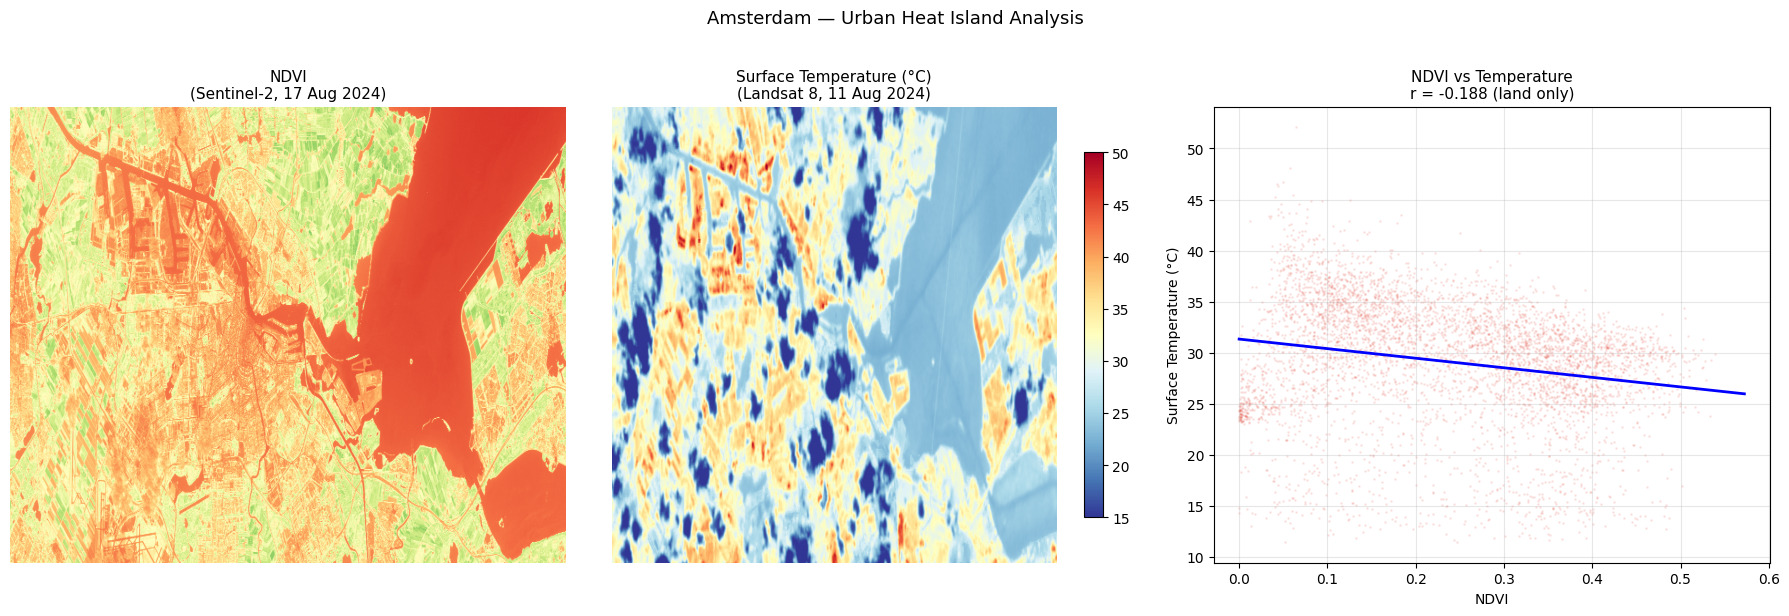

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Mappa 1 — NDVI
axes[0].imshow(ndvi_resampled, cmap='RdYlGn', vmin=-0.2, vmax=0.8, aspect='auto')
axes[0].set_title('NDVI\n(Sentinel-2, 17 Aug 2024)', fontsize=11)
axes[0].set_axis_off()

# Mappa 2 — Temperatura
img2 = axes[1].imshow(st_celsius_ams, cmap='RdYlBu_r', vmin=15, vmax=50, aspect='auto')
axes[1].set_title('Surface Temperature (°C)\n(Landsat 8, 11 Aug 2024)', fontsize=11)
axes[1].set_axis_off()
plt.colorbar(img2, ax=axes[1], shrink=0.8)

# Grafico 3 — Correlazione
# Campionamento casuale per velocità
idx = np.random.choice(len(ndvi_land), 5000, replace=False)
axes[2].scatter(ndvi_land[idx], temp_land[idx], 
                alpha=0.1, s=1, color='#e74c3c')

z = np.polyfit(ndvi_land[idx], temp_land[idx], 1)
x_line = np.linspace(ndvi_land.min(), ndvi_land.max(), 100)
axes[2].plot(x_line, np.poly1d(z)(x_line), 'b-', linewidth=2)

axes[2].set_xlabel('NDVI')
axes[2].set_ylabel('Surface Temperature (°C)')
axes[2].set_title(f'NDVI vs Temperature\nr = {r2:.3f} (land only)', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Amsterdam — Urban Heat Island Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('amsterdam_heat_ndvi_correlation.png', dpi=150, bbox_inches='tight')
plt.show()